In [1]:
import h5py
import numpy as np

h5_file = h5py.File('/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/2x2_ELECTRON_SAMPLES/HDF5/electron_2x2_10MeVto2GeV_100k.7449.LARCV2HDF5.hdf5', 'r')

In [2]:
event_idx = 22

vx_start = int(h5_file['voxels_offsets'][event_idx])
vx_end = int(h5_file['voxels_offsets'][event_idx + 1])

event_vx = h5_file['voxels_flat'][vx_start:vx_end]
ke = h5_file['ke_initial'][event_idx]


start_point = h5_file['start_points'][event_idx]

print("Event index:", event_idx)
print("Initial kinetic energy:", ke)
print("Number of voxels in event:", len(event_vx))
#print("First 10 voxels (x, y, z, dE):")
#for i in range(min(10, len(event_vx))):
#    print(f"  {i}: ({event_vx[i][0]}, {event_vx[i][1]}, {event_vx[i][2]}, {event_vx[i][3]})")
#print("Sum of energy:", np.sum(event_vx[:, 3]))  # Sum of dE values
positions_cm = event_vx[:, :3]  # Get the positions in cm
energy_per_voxel = event_vx[:, 3]  # Get the energy per voxel
#print("Positions (cm):", positions_cm[:10])  # Print first 10 positions
#print("Energy per voxel (MeV):", energy_per_voxel[:10])  #
#print("Number of events:", h5_file.attrs['n_events'])
distance_point_to_origin = np.linalg.norm(positions_cm, axis=1)
print("Minimum distance from origin to any voxel:", np.min(distance_point_to_origin))
print("Voxel with minimum distance from origin:", positions_cm[np.argmin(distance_point_to_origin)], "with energy:", energy_per_voxel[np.argmin(distance_point_to_origin)])
print("Voxel with minimum distance from origin:", np.argmin(distance_point_to_origin), "with energy:", energy_per_voxel[np.argmin(distance_point_to_origin)])
print("Start point:",start_point)
positions_to_use = positions_cm - start_point
positions_to_use_mask = positions_to_use[:, 2] > -60  # Filter for positions with z > 0
print("Positions to use:", positions_to_use[positions_to_use_mask])
print("Positions original:", positions_cm[positions_to_use_mask])
print("Energy per voxel to use:", np.sum(energy_per_voxel[positions_to_use_mask]))

IndexError: Index (22) out of range for (0-0)

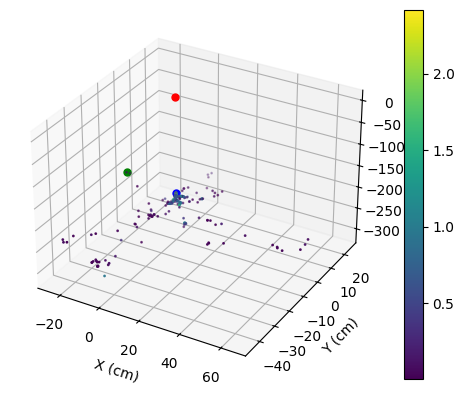

In [13]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

shower_x = event_vx[:, 0]
shower_y = event_vx[:, 1]
shower_z = event_vx[:, 2]
shower_dE = event_vx[:, 3]

shower = ax.scatter(shower_x,shower_y,shower_z,c=shower_dE, cmap='viridis', s=1)
ax.plot(0,0,0, marker='o', markersize=5, color='red')  # Mark the origin
ax.plot(start_point[0], start_point[1], start_point[2], marker='o', markersize=5, color='blue')  # Mark the start point
ax.plot(positions_cm[np.argmin(distance_point_to_origin)][0], positions_cm[np.argmin(distance_point_to_origin)][1], positions_cm[np.argmin(distance_point_to_origin)][2], marker='o', markersize=5, color='green')  # Mark the voxel closest to the origin
ax.set_xlabel('X (cm)')
ax.set_ylabel('Y (cm)')
ax.set_zlabel('Z (cm)')
cbar = plt.colorbar(shower)

In [14]:
import numpy as np
import plotly.graph_objects as go

# assume: event_vx, start_point, positions_cm, distance_point_to_origin already defined
shower_x = event_vx[:, 0]
shower_y = event_vx[:, 1]
shower_z = event_vx[:, 2]
shower_dE = event_vx[:, 3]

closest_idx = int(np.argmin(distance_point_to_origin))
closest_pt = positions_cm[closest_idx]

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=shower_x, y=shower_y, z=shower_z,
    mode='markers',
    marker=dict(size=2, color=shower_dE, colorscale='Viridis', colorbar=dict(title='dE'), opacity=0.8),
    name='voxels'
))

fig.add_trace(go.Scatter3d(x=[0], y=[0], z=[0],
    mode='markers', marker=dict(size=6, color='red'), name='origin'))

fig.add_trace(go.Scatter3d(x=[start_point[0]], y=[start_point[1]], z=[start_point[2]],
    mode='markers', marker=dict(size=6, color='blue'), name='start'))

fig.add_trace(go.Scatter3d(x=[closest_pt[0]], y=[closest_pt[1]], z=[closest_pt[2]],
    mode='markers', marker=dict(size=6, color='green'), name='closest voxel'))

fig.update_layout(
    title='Shower voxels (colored by dE)',
    scene=dict(xaxis_title='X (cm)', yaxis_title='Y (cm)', zaxis_title='Z (cm)'),
    legend=dict(itemsizing='constant')
)

fig.show()

In [4]:
import ROOT
fname = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/PHOTON_SAMPLES/LARCV/photon_10MeVto2GeV_TEST.1000.LARCV.root' # Change this path if you are not on NERSC
#fname = 'LOCAL_PATH'
f = ROOT.TFile(fname)
f.ls()

Warning in <TClass::Init>: no dictionary for class larcv::EventSparseTensor3D is available


TFile**		/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/PHOTON_SAMPLES/LARCV/photon_10MeVto2GeV_TEST.1000.LARCV.root	
 TFile*		/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/PHOTON_SAMPLES/LARCV/photon_10MeVto2GeV_TEST.1000.LARCV.root	
  KEY: TTree	sparse3d_pcluster_tree;1	pcluster tree
  KEY: TTree	sparse3d_pcluster_semantics_tree;1	pcluster_semantics tree
  KEY: TTree	cluster3d_pcluster_tree;1	pcluster tree
  KEY: TTree	cluster3d_pcluster_dedx_tree;1	pcluster_dedx tree
  KEY: TTree	particle_pcluster_tree;1	pcluster tree


Warning in <TClass::Init>: no dictionary for class larcv::EventBase is available
Warning in <TClass::Init>: no dictionary for class larcv::SparseTensor3D is available
Warning in <TClass::Init>: no dictionary for class larcv::VoxelSet is available
Warning in <TClass::Init>: no dictionary for class larcv::Voxel is available
Warning in <TClass::Init>: no dictionary for class larcv::Voxel3DMeta is available
Warning in <TClass::Init>: no dictionary for class larcv::BBox3D is available
Warning in <TClass::Init>: no dictionary for class larcv::Point3D is available
Warning in <TClass::Init>: no dictionary for class larcv::EventClusterVoxel3D is available
Warning in <TClass::Init>: no dictionary for class larcv::ClusterVoxel3D is available
Warning in <TClass::Init>: no dictionary for class larcv::VoxelSetArray is available
Warning in <TClass::Init>: no dictionary for class larcv::EventParticle is available
Warning in <TClass::Init>: no dictionary for class larcv::ParticleSet is available
Warnin

In [5]:
import larcv
import sys
sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/spine/')
import spine
from spine.io.dataset.larcv import LArCVDataset
tree = f.Get("particle_pcluster_tree")

print('Number of entries', tree.GetEntries())
energy_init_values = []
start_x = []
start_y = []
start_z = []

for entry in range(tree.GetEntries()):
    if entry != event_idx: continue
    tree.GetEntry(entry)
    event = tree.particle_pcluster_branch
    print("Event:", entry)
    particles = event.as_vector()
    #print("Number of particles = ", len(particles))
    #print(particles[0].id())
    print("Children of first particle:")
    photon_id = particles[0].id()
    child_particles = [p for p in particles[1:] if p.parent_id() == photon_id ]
    print("Number of child particles = ", len(child_particles))
    first_child_idx = np.argmin([p.t() for p in child_particles])
    print([p.t() for p in child_particles])
    print(first_child_idx)
    print('First child position:', (child_particles[first_child_idx].x(), child_particles[first_child_idx].y(), child_particles[first_child_idx].z()))
    #for i in range(len(particles)):
        #if particles[i].parent_id() == particles[0].id():
         #   print("  Particle ID:", particles[i].id(), "Parent ID:", particles[i].parent_id(), "PDG Code:", particles[i].pdg_code(), "Creation Process:", particles[i].creation_process(), "Time:", particles[i].t(), "Energy Init:", particles[i].energy_init(), "Start Position:", (particles[i].x(), particles[i].y(), particles[i].z()))
    #for i in range(len(particles)):
    #    energy_init_values.append(particles[i].energy_init())
    #    start_x.append(particles[i].x())
    #    start_y.append(particles[i].y())
    #    start_z.append(particles[i].z())

#print("Energy init values:", energy_init_values)
#print("Start x:", start_x)
#print("Start y:", start_y)
#print("Start z:", start_z)
energy_init_values = np.array(energy_init_values)
start_x = np.array(start_x)
start_y = np.array(start_y)
start_z = np.array(start_z)

Number of entries 50
Event: 9
Children of first particle:
Number of child particles =  2
[1115.100084, 1115.100084]
0
First child position: (0.0, 0.0, -3.4506129999999997)


In [2]:
# Check data loading 
import sys 
sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/')
from utils.data_loader import get_data_loader

In [5]:
#Test dataloader
import os
sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/utils/')
from parse_yaml import ParseYAML
import argparse
#import os
os.chdir('/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/')

yaml_config='./configs/NDLAr_sheep.yaml'
config="weighted_mse_lin"
results_dir="./outputs"
run_num = 'test_data_loader'
#ckpt_file = 'ckpt_epoch_0_iters_25_best.tar'
params = ParseYAML(os.path.abspath(yaml_config), config)

params['local_batch_size'] = 50
params['num_data_workers'] = 4
#params['train_path'] = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/'

train_data_loader, train_sampler = get_data_loader(params, params['train_path'], False, train=True)


for i, (inputs, targets, VE_frac, MG_frac, OOB_frac, start_pos, rot_mat, idx) in enumerate(train_data_loader):
    
    if i>1: break
    print("Inputs shape:", inputs.shape)
    print("Targets shape:", targets.shape)
    print("Inputs initial entries:", inputs[:10])  # Check batch indices
    mask_first_event = inputs[:,0] == 0
    inputs_masked = inputs[mask_first_event]
    inputs_masked_x = np.array(inputs_masked[:, 1])
    inputs_masked_y = np.array(inputs_masked[:, 2])
    inputs_masked_z = np.array(inputs_masked[:, 3])
    inputs_masked_dE = np.array(inputs_masked[:, 4])



Getting data loader for mode  train  with data location  /pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/NDLAR_ELECTRON_SAMPLES/HDF5/TRAIN/
Applying energy threshold of 0.2 MeV to features. Number of voxels before thresholding: 11932
Applied energy threshold of 0.2 MeV. Number of voxels after thresholding: 6187
Applying energy threshold of 0.2 MeV to features. Number of voxels before thresholding: 14318
Applied energy threshold of 0.2 MeV. Number of voxels after thresholding: 6960
Applying energy threshold of 0.2 MeV to features. Number of voxels before thresholding: 2508
Applied energy threshold of 0.2 MeV. Number of voxels after thresholding: 1217
Applying energy threshold of 0.2 MeV to features. Number of voxels before thresholding: 1552
Applied energy threshold of 0.2 MeV. Number of voxels after thresholding: 824
Applying energy threshold of 0.2 MeV to features. Number of voxels before thresholding: 4510
Applied energy threshold of 0.2 MeV. Number of voxels after thresholding: 23

NameError: name 'np' is not defined

In [13]:
for i, (inputs, targets, VE_frac, MG_frac, OOB_frac, start_pos, rot_mat, idx) in enumerate(train_data_loader):
    
    if i>1: break
    print("Inputs shape:", inputs.shape)
    print("Targets shape:", targets.shape)
    print("Inputs initial entries:", inputs[:10])  # Check batch indices
    mask_first_event = inputs[:,0] == 0
    inputs_masked = inputs[mask_first_event]
    inputs_masked_x = np.array(inputs_masked[:, 1])
    inputs_masked_y = np.array(inputs_masked[:, 2])
    inputs_masked_z = np.array(inputs_masked[:, 3])
    inputs_masked_dE = np.array(inputs_masked[:, 4])
    print("Batch numbers for first batch:", np.unique(inputs[:,0]))

Inputs shape: torch.Size([25735, 5])
Targets shape: torch.Size([50, 1])
Inputs initial entries: tensor([[0.0000e+00, 2.0900e+02, 2.6000e+01, 6.0000e+00, 6.7223e-03],
        [0.0000e+00, 2.1400e+02, 3.0000e+01, 1.5000e+01, 1.4860e-02],
        [0.0000e+00, 2.2000e+02, 3.2000e+01, 7.0000e+00, 1.6688e-02],
        [0.0000e+00, 2.2100e+02, 1.0000e+00, 2.0000e+00, 4.7764e+00],
        [0.0000e+00, 2.2100e+02, 2.0000e+00, 3.0000e+00, 7.5071e-01],
        [0.0000e+00, 2.2100e+02, 2.9000e+01, 9.0000e+00, 7.0235e-02],
        [0.0000e+00, 2.2200e+02, 0.0000e+00, 1.0000e+00, 6.4284e-01],
        [0.0000e+00, 2.2200e+02, 2.0000e+00, 2.0000e+00, 1.6004e-01],
        [0.0000e+00, 2.2400e+02, 3.8000e+01, 2.2000e+01, 4.4640e-02],
        [0.0000e+00, 2.2400e+02, 3.9000e+01, 2.1000e+01, 9.9225e-03]])
Batch numbers for first batch: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 4